Вариант 17: Визуализация


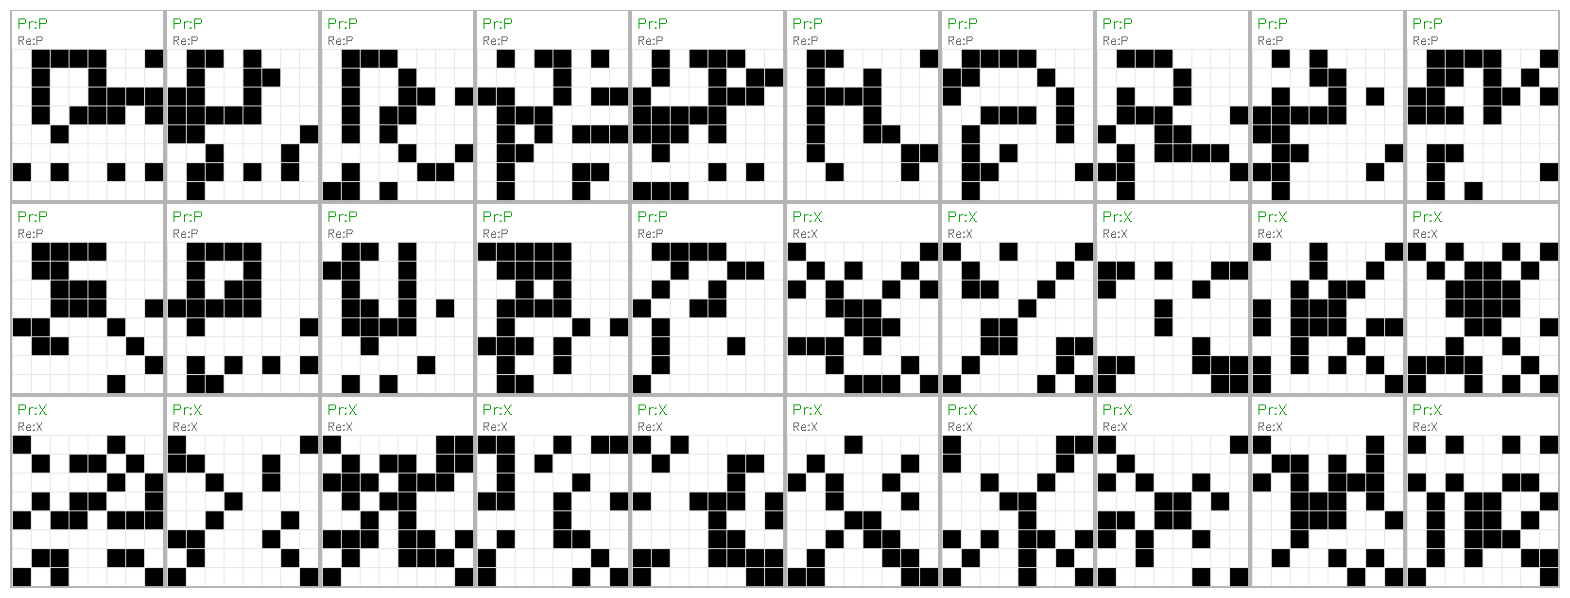

In [8]:
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt

def generate_samples():
    def add_noise(matrix, p=0.2):
        noise = np.random.choice([0, 1], size=(8, 8), p=[1-p, p])
        return np.logical_xor(matrix, noise).astype(int)

    base_P = np.zeros((8, 8))
    base_P[:, 1] = 1; base_P[0, 1:5] = 1; base_P[3, 1:5] = 1; base_P[1:3, 4] = 1

    base_X = np.eye(8); base_X = base_X + np.fliplr(base_X)
    base_X[base_X > 1] = 1

    train_P = [add_noise(base_P) for _ in range(15)]
    train_X = [add_noise(base_X) for _ in range(15)]
    return np.array(train_P), np.array(train_X)

class MatrixBayes:
    def fit(self, X_data, labels):
        self.classes = np.unique(labels)
        self.probs = {}
        for c in self.classes:
            class_matrices = X_data[labels == c]
            p = (np.sum(class_matrices, axis=0) + 0.01) / (len(class_matrices) + 0.02)
            self.probs[c] = p

    def predict(self, matrix):
        results = {}
        for c in self.classes:
            p_map = self.probs[c]
            prob_matrix = np.where(matrix == 1, p_map, 1 - p_map)
            results[c] = np.sum(np.log(prob_matrix))
        return max(results, key=results.get)

def draw_perfect_grid(samples_P, samples_X, model):
    all_imgs = []
    pairs = [('P', s) for s in samples_P] + [('X', s) for s in samples_X]

    cell_size = 20

    for real, mat in pairs:
        pred = model.predict(mat)

        img = np.full((8 * cell_size, 8 * cell_size, 3), 255, dtype=np.uint8)
        for r in range(8):
            for c in range(8):
                color = (0, 0, 0) if mat[r, c] == 1 else (255, 255, 255)
                cv2.rectangle(img, (c*cell_size, r*cell_size),
                             ((c+1)*cell_size, (r+1)*cell_size), color, -1)
                cv2.rectangle(img, (c*cell_size, r*cell_size),
                             ((c+1)*cell_size, (r+1)*cell_size), (230, 230, 230), 1)

        img = cv2.copyMakeBorder(img, 40, 0, 0, 0, cv2.BORDER_CONSTANT, value=(255, 255, 255))

        color = (0, 150, 0) if pred == real else (0, 0, 255)
        cv2.putText(img, f"Pr:{pred}", (5, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cv2.putText(img, f"Re:{real}", (5, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1)

        img = cv2.copyMakeBorder(img, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=(180, 180, 180))
        all_imgs.append(img)

    rows = [np.hstack(all_imgs[i:i+10]) for i in range(0, 30, 10)]
    final_grid = np.vstack(rows)

    print("Вариант 17: Визуализация")
    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(final_grid, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    #Альтернатива визуализации для google collab
    # cv2_imshow(final_grid)

P_samples, X_samples = generate_samples()
X_train = np.vstack([P_samples, X_samples])
y_train = np.array(['P']*15 + ['X']*15)

model = MatrixBayes()
model.fit(X_train, y_train)

draw_perfect_grid(P_samples, X_samples, model)